# Geometry, mesh, and enlarged cells

This CPU-only notebook introduces the public `fdtdmesh` workflow. Geometry is continuous and immutable; meshes are derived inspection/solver grids.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/fdtdmesh").is_dir())
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import matplotlib.pyplot as plt

import fdtdmesh as fd

OUT = ROOT / "artifacts" / "notebooks"
OUT.mkdir(parents=True, exist_ok=True)


def keep(fig, name):
    fig.savefig(OUT / name, dpi=140, bbox_inches="tight")
    return fig

## Define a continuous scene

The six-wavelength square gives the default PML/TFSF layout room to operate. The PEC cylinder is centered at `(3λ, 3λ)` and has radius `0.47λ`.

{'size': (1.798754748, 1.798754748), 'units': 'SI', 'geometry_id': '361717120bf9333b015a484a79350d534d9cc7ad67e6f4956df2509dc569cdfd', 'fmin': 900000000.0, 'fmax': 1100000000.0, 'frequencies': [900000000.0, 910000000.0, 920000000.0, 930000000.0, 940000000.0, 950000000.0, 960000000.0, 970000000.0, 980000000.0, 990000000.0, 1000000000.0, 1010000000.0, 1020000000.0, 1030000000.0, 1040000000.0, 1050000000.0, 1060000000.0, 1070000000.0, 1080000000.0, 1090000000.0, 1100000000.0], 'pulse': {'fmin': 900000000.0, 'fmax': 1100000000.0, 'edge_level_db': -6.0, 'cutoff': 5.0}, 'source_end': np.float64(2.6455659908195025e-08), 'significant_frequency': np.float64(1258198889.7471611), 'layout': {'tfsf_box': (0.449688687, 1.349066061, 0.449688687, 1.349066061), 'contour_box': (0.299792458, 1.4989622900000001, 0.299792458, 1.4989622900000001), 'source_x': 0.2248443435, 'origin': (0.899377374, 0.899377374)}, 'pml': {'x': {'cells': 12, 'thickness': 0.149896229}, 'y': {'cells': 12, 'thickness': 0.149896229

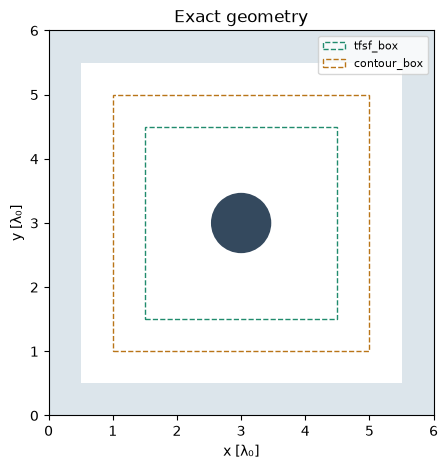

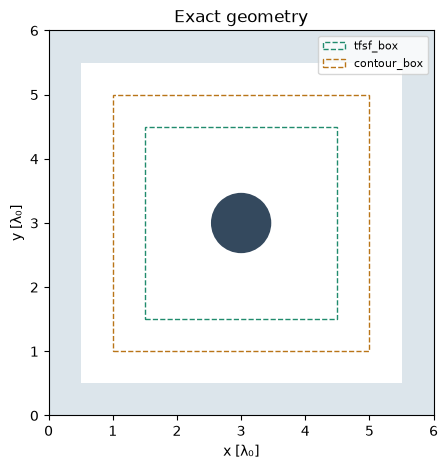

In [3]:
lam = fd.C0 / 1.0e9
sim = fd.Simulation(
    size=(6 * lam, 6 * lam), fmin=0.9e9, fmax=1.1e9, settings=fd.SolverSettings(dft_bins=21)
)
handle = sim.add_circle(center=(3 * lam, 3 * lam), radius=0.47 * lam, name="canonical-cylinder")
geometry_id = sim.geometry.geometry_id
print(sim.summary())
keep(sim.plot_geometry(mesh=False, units="wavelength"), "01_exact_geometry.png")

## Uniform grid and discretization

`apply_mesh` prepares the CPU inspection state. The exact geometry view overlays the Yee grid; the discretization view marks cut faces and enlarged donor pairs.

uniform mesh: {'size': (1.798754748, 1.798754748), 'units': 'SI', 'geometry_id': '361717120bf9333b015a484a79350d534d9cc7ad67e6f4956df2509dc569cdfd', 'fmin': 900000000.0, 'fmax': 1100000000.0, 'frequencies': [900000000.0, 910000000.0, 920000000.0, 930000000.0, 940000000.0, 950000000.0, 960000000.0, 970000000.0, 980000000.0, 990000000.0, 1000000000.0, 1010000000.0, 1020000000.0, 1030000000.0, 1040000000.0, 1050000000.0, 1060000000.0, 1070000000.0, 1080000000.0, 1090000000.0, 1100000000.0], 'pulse': {'fmin': 900000000.0, 'fmax': 1100000000.0, 'edge_level_db': -6.0, 'cutoff': 5.0}, 'source_end': np.float64(2.6455659908195025e-08), 'significant_frequency': np.float64(1258198889.7471611), 'layout': {'tfsf_box': (0.449688687, 1.349066061, 0.449688687, 1.349066061), 'contour_box': (0.299792458, 1.4989622900000001, 0.299792458, 1.4989622900000001), 'source_x': 0.2248443435, 'origin': (0.899377374, 0.899377374)}, 'pml': {'x': {'cells': 12, 'thickness': 0.149896229}, 'y': {'cells': 12, 'thickness

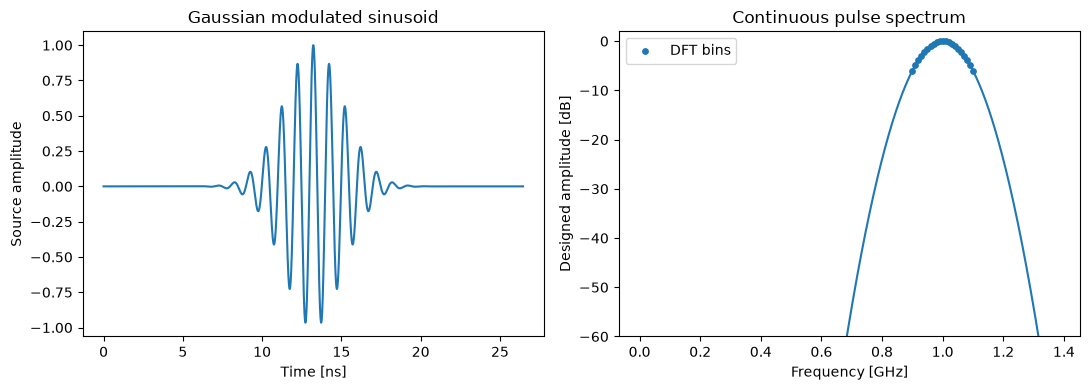

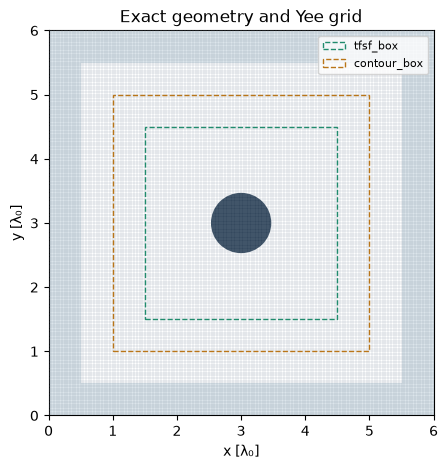

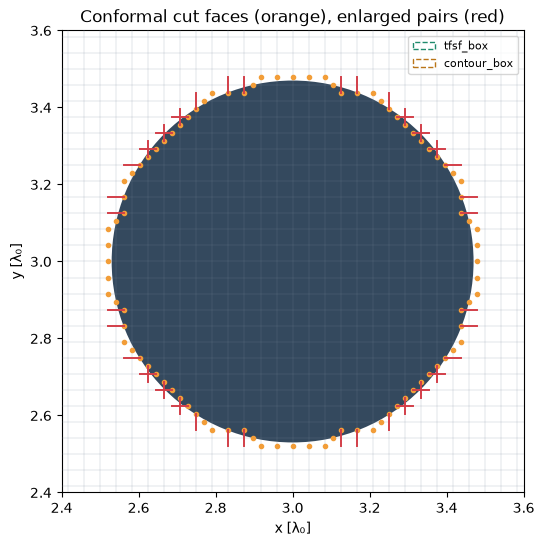

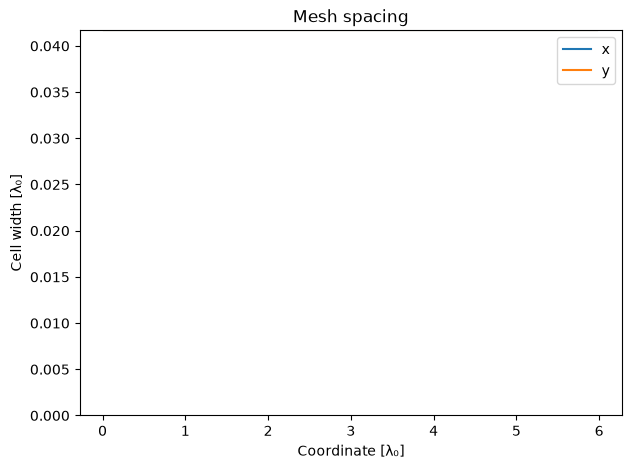

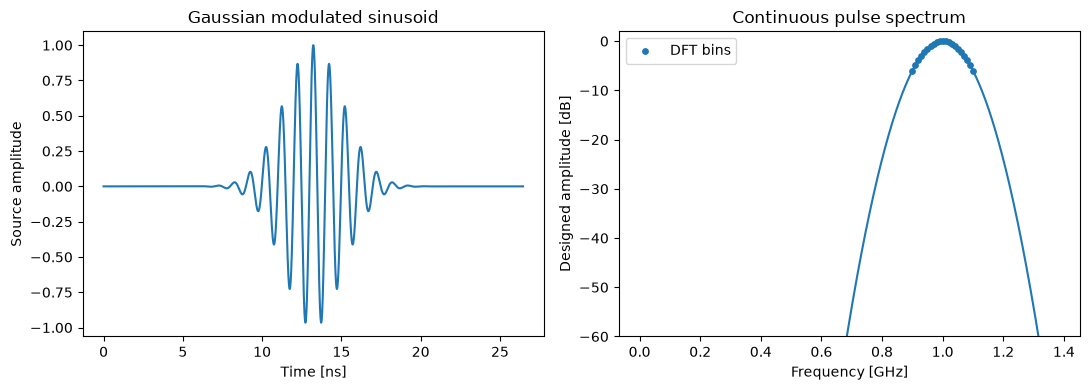

In [4]:
sim.apply_mesh("uniform", cells=(144, 144))
print("uniform mesh:", sim.summary())
keep(sim.plot_geometry(mesh=True, units="wavelength"), "02_exact_geometry_plus_grid.png")
fig, ax = plt.subplots(figsize=(7, 6))
sim.plot_discretization(units="wavelength", ax=ax)
ax.set(xlim=(2.4, 3.6), ylim=(2.4, 3.6))
keep(fig, "03_discretization_enlarged_pairs.png")
keep(sim.plot_mesh(units="wavelength"), "04_uniform_mesh_spacing.png")
keep(sim.plot_source(), "05_source.png")

## Deterministic remesh and CNN raster input

A deterministic mesh changes only the derived discretization. The geometry identity remains the same. `rasterize` is a mesh-independent pixel representation for CNN input; it is not the authority for solver geometry.

CNN raster shape: (3, 128, 128) geometry id: 361717120bf9333b015a484a79350d534d9cc7ad67e6f4956df2509dc569cdfd


remeshed geometry id: 361717120bf9333b015a484a79350d534d9cc7ad67e6f4956df2509dc569cdfd


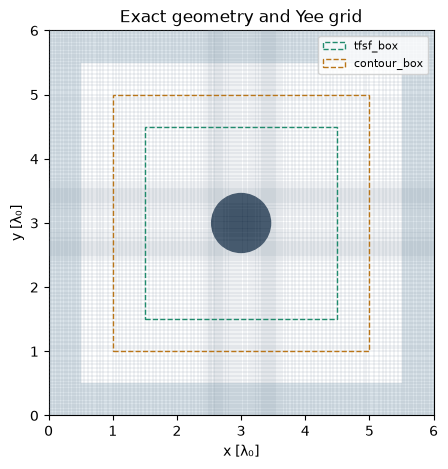

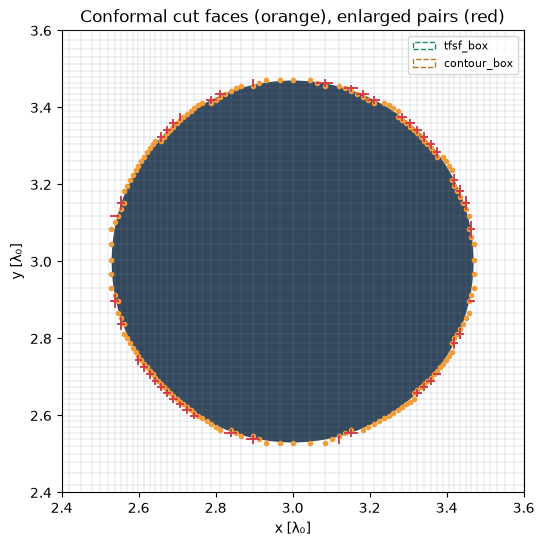

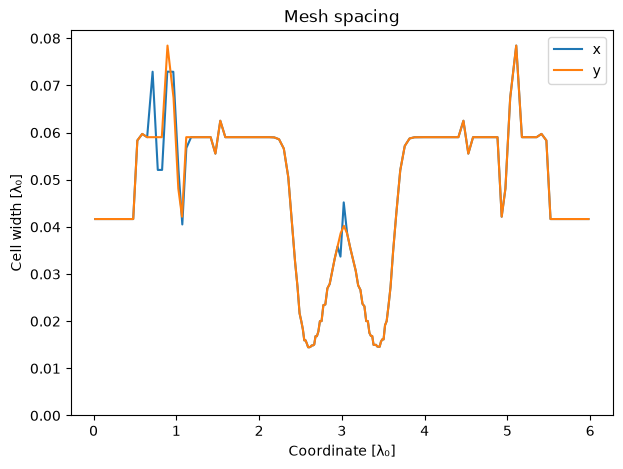

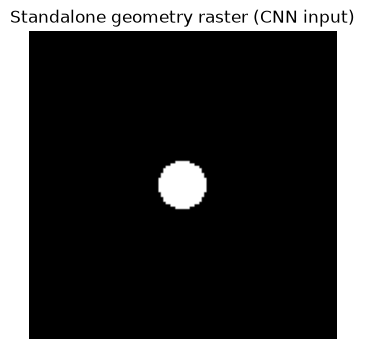

In [5]:
raster = sim.geometry.rasterize((128, 128), channels=("occupancy", "x", "y"))
print("CNN raster shape:", raster.shape, "geometry id:", geometry_id)
sim.apply_mesh("deterministic", cells=(144, 144))
print("remeshed geometry id:", sim.geometry.geometry_id)
assert sim.geometry.geometry_id == geometry_id
keep(sim.plot_geometry(mesh=True, units="wavelength"), "06_deterministic_geometry_plus_grid.png")
fig, ax = plt.subplots(figsize=(7, 6))
sim.plot_discretization(units="wavelength", ax=ax)
ax.set(xlim=(2.4, 3.6), ylim=(2.4, 3.6))
keep(fig, "07_deterministic_discretization.png")
keep(sim.plot_mesh(units="wavelength"), "08_deterministic_mesh_spacing.png")
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(raster[0], origin="lower", cmap="gray")
ax.set_title("Standalone geometry raster (CNN input)")
ax.axis("off")
fig.savefig(OUT / "09_geometry_raster.png", dpi=140, bbox_inches="tight")

The continuous `Geometry` object controls material occupancy and its stable `geometry_id`; remeshing changes cell locations and coefficients while preserving that identity.

Add circles, rectangles, or simple polygons with `material="PEC"` (default) or `"air"`. Later regions overwrite earlier interiors; touching same-material regions merge. The solver rejects cut topology or donor arrangements that it cannot represent. Refining a mesh does not guarantee every corner alignment will be supported. See the [API guide](../docs/solver_api.md) for shape handles, checkpoint meshes, and archives.